# SynthACticBench O1: 1,500-trial leaf policies

Problem seed 53, `min_samples_split=1`, and five SMAC seeds. The staged policy uses leaf size 3 for trials 1–500, leaf size 2 for trials 501–1,000, and leaf size 1 for trials 1,001–1,500.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path("/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o1_deterministic/leaf_policies/05_more_iterations")
OUTPUT_DIRECTORY = HERE / "smac_output"
POLICIES = ("fixed_leaf_1", "fixed_leaf_2", "fixed_leaf_3", "staged_leaf_3_2_1")
SEEDS = tuple(range(5))
N_TRIALS = 1500
CHECKPOINTS = tuple(range(100, N_TRIALS + 1, 100))
LABELS = {
    "fixed_leaf_1": "fixed leaf = 1",
    "fixed_leaf_2": "fixed leaf = 2",
    "fixed_leaf_3": "fixed leaf = 3",
    "staged_leaf_3_2_1": "staged 3 → 2 → 1",
}

In [2]:
def load_results(policy):
    by_seed = {}
    for path in (OUTPUT_DIRECTORY / policy).rglob("trajectory.json"):
        result = json.loads(path.read_text())
        seed = result["smac_seed"]
        if seed in SEEDS and result["n_trials"] == N_TRIALS:
            if seed not in by_seed or path.stat().st_mtime > by_seed[seed][0]:
                by_seed[seed] = (path.stat().st_mtime, result)
    missing = sorted(set(SEEDS) - set(by_seed))
    if missing:
        raise FileNotFoundError(f"Missing completed runs for {policy}, seeds={missing}")
    return {seed: by_seed[seed][1] for seed in SEEDS}


results = {policy: load_results(policy) for policy in POLICIES}
for runs in results.values():
    for result in runs.values():
        assert result["problem_seed"] == 53
        assert result["min_samples_split"] == 1
        assert result["n_trials"] == N_TRIALS
        assert min(result["regret"]) >= -1e-8
for seed in SEEDS:
    staged = results["staged_leaf_3_2_1"][seed]
    assert staged["stage_boundaries"] == [500, 1000]
    assert staged["objective_value"][:500] == results["fixed_leaf_3"][seed]["objective_value"][:500]
print(f"Loaded {sum(len(runs) for runs in results.values())}/20 validated trajectories.")
print("Known global minimum:", results["fixed_leaf_1"][0]["f_min"])
print("Staged transitions:")
for seed in SEEDS:
    print(seed, results["staged_leaf_3_2_1"][seed]["transitions"])

Loaded 20/20 validated trajectories.
Known global minimum: -267554.1673176964
Staged transitions:
0 [[0, 3], [500, 2], [1000, 1]]
1 [[0, 3], [500, 2], [1000, 1]]
2 [[0, 3], [500, 2], [1000, 1]]
3 [[0, 3], [500, 2], [1000, 1]]
4 [[0, 3], [500, 2], [1000, 1]]


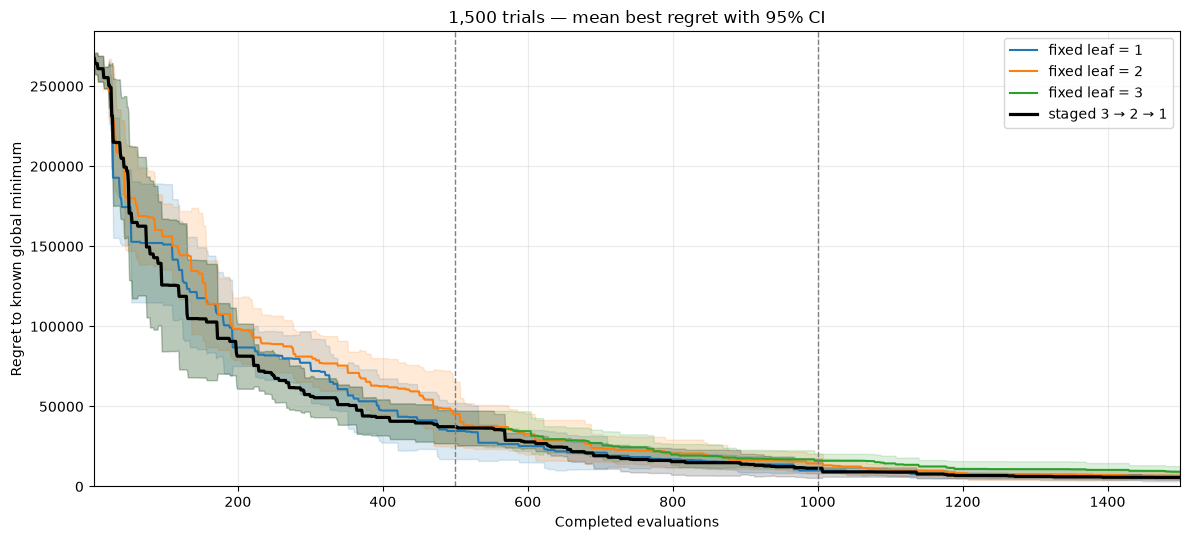

In [3]:
rows = []
for policy, runs in results.items():
    for seed, result in runs.items():
        rows.extend(
            {"policy": policy, "smac_seed": seed, "iteration": i, "best_regret": regret}
            for i, regret in zip(result["iteration"], result["best_regret"])
        )
trajectories = pd.DataFrame(rows)
summary = (
    trajectories.groupby(["policy", "iteration"])["best_regret"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
summary["ci95"] = 1.96 * summary["std"].fillna(0) / np.sqrt(summary["count"])

fig, ax = plt.subplots(figsize=(12, 5.5))
for policy in POLICIES:
    data = summary[summary["policy"] == policy]
    x, mean, ci = data["iteration"].to_numpy(), data["mean"].to_numpy(), data["ci95"].to_numpy()
    style = {"color": "black", "linewidth": 2.3} if policy == "staged_leaf_3_2_1" else {}
    line = ax.plot(x, mean, label=LABELS[policy], **style)[0]
    ax.fill_between(x, np.maximum(0, mean - ci), mean + ci, color=line.get_color(), alpha=0.16)
ax.axvline(500, color="grey", linestyle="--", linewidth=1)
ax.axvline(1000, color="grey", linestyle="--", linewidth=1)
ax.set(title="1,500 trials — mean best regret with 95% CI", xlabel="Completed evaluations", ylabel="Regret to known global minimum", xlim=(1, N_TRIALS))
ax.set_ylim(bottom=0)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

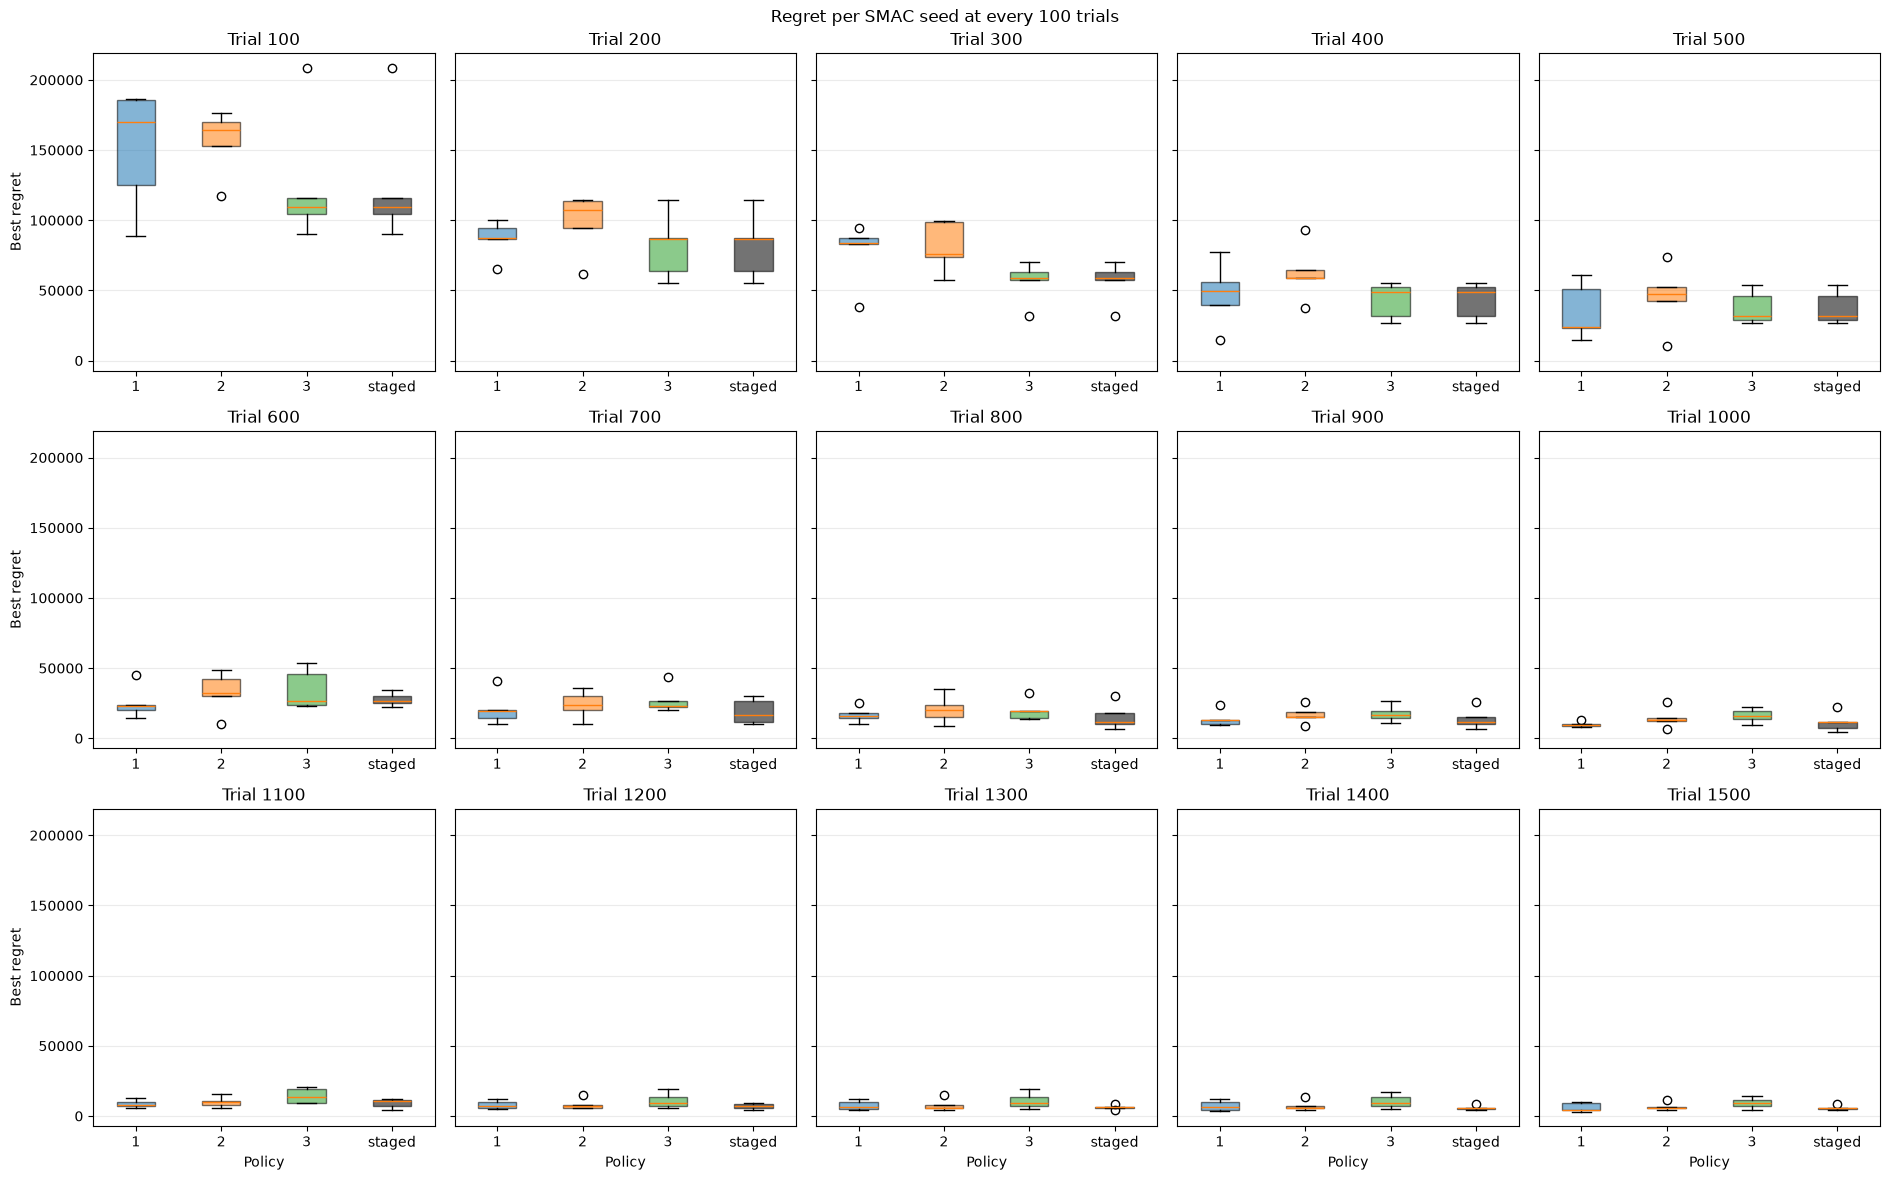

In [4]:
fig, axes = plt.subplots(3, 5, figsize=(19, 12), sharey=True)
for ax, checkpoint in zip(axes.flat, CHECKPOINTS):
    values = [
        [results[policy][seed]["best_regret"][checkpoint - 1] for seed in SEEDS]
        for policy in POLICIES
    ]
    boxes = ax.boxplot(values, patch_artist=True, tick_labels=["1", "2", "3", "staged"])
    for box, color in zip(boxes["boxes"], ("C0", "C1", "C2", "black")):
        box.set(facecolor=color, alpha=0.55)
    ax.set_title(f"Trial {checkpoint}")
    ax.grid(axis="y", alpha=0.25)
for ax in axes[:, 0]:
    ax.set_ylabel("Best regret")
for ax in axes[-1, :]:
    ax.set_xlabel("Policy")
fig.suptitle("Regret per SMAC seed at every 100 trials")
plt.tight_layout()
plt.show()

In [5]:
(
    trajectories[trajectories["iteration"].isin(CHECKPOINTS)]
    .groupby(["iteration", "policy"])["best_regret"]
    .agg(["mean", "std", "min", "median", "max"])
)

mean           std            min  \
iteration policy                                                          
100       fixed_leaf_1       151097.759790  43030.700062   88562.054742   
          fixed_leaf_2       156159.754774  23449.120374  117177.667369   
          fixed_leaf_3       125805.684848  47245.691990   90406.646313   
          staged_leaf_3_2_1  125805.684848  47245.691990   90406.646313   
200       fixed_leaf_1        86797.185508  13157.074573   65593.074687   
          fixed_leaf_2        98419.286907  22205.680590   61547.309564   
          fixed_leaf_3        81394.497072  23198.736946   55442.755310   
          staged_leaf_3_2_1   81394.497072  23198.736946   55442.755310   
300       fixed_leaf_1        77277.119296  22390.221641   38009.606833   
          fixed_leaf_2        81118.273564  18004.624502   57488.890174   
          fixed_leaf_3        56275.478907  14513.538051   32006.761929   
          staged_leaf_3_2_1   56275.478907  14513.538051   32006.761929   
400       fixed_leaf_1        47424.256559  22822.373799   14995.976992   
          fixed_leaf_2        62589.090882  19966.994599   37385.122812   
          fixed_leaf_3        43149.035830  12811.185357   26988.591710   
          staged_leaf_3_2_1   43149.035830  12811.185357   26988.591710   
500       fixed_leaf_1        34650.175745  20002.916089   14812.467730   
          fixed_leaf_2        45288.487353  22940.683315   10193.255947   
          fixed_leaf_3        37348.609639  11830.947509   26608.490093   
          staged_leaf_3_2_1   37348.609639  11830.947509   26608.490093   
600       fixed_leaf_1        25234.121671  11548.998981   14812.467730   
          fixed_leaf_2        32673.168411  14543.088973   10193.255947   
          fixed_leaf_3        34564.028710  14128.050514   23273.805643   
          staged_leaf_3_2_1   27821.965079   4603.064107   22637.066182   
700       fixed_leaf_1        21127.580320  11796.201985   10116.580885   
          fixed_leaf_2        24078.467118   9696.386938   10193.255947   
          fixed_leaf_3        27165.594985   9451.609318   20153.907905   
          staged_leaf_3_2_1   19191.555136   8928.287399   10389.719283   
800       fixed_leaf_1        16863.407578   5647.385863   10116.580885   
          fixed_leaf_2        20595.191846   9872.342632    8739.570976   
          fixed_leaf_3        19953.453225   7503.454798   13980.516225   
          staged_leaf_3_2_1   15506.413222   9323.376613    6464.888379   
900       fixed_leaf_1        13895.764740   5731.712204    9120.002257   
          fixed_leaf_2        16584.748677   6339.844476    8410.535952   
          fixed_leaf_3        17605.607077   6010.005474   10544.770500   
          staged_leaf_3_2_1   13945.096912   7366.010692    6464.888379   
1000      fixed_leaf_1         9992.791639   1930.775953    8142.493294   
          fixed_leaf_2        14388.890314   6952.632706    6447.923633   
          fixed_leaf_3        16080.433192   4946.308323    9528.173348   
          staged_leaf_3_2_1   11417.407738   6894.225716    4202.789026   
1100      fixed_leaf_1         8814.124900   2738.724358    5934.723703   
          fixed_leaf_2        10143.755115   3727.284051    5978.926304   
          fixed_leaf_3        14388.431813   5525.459528    9062.472116   
          staged_leaf_3_2_1    9026.140458   3344.496059    4202.789026   
1200      fixed_leaf_1         7828.210860   2980.661299    4795.228832   
          fixed_leaf_2         8309.630260   3855.674264    5616.084162   
          fixed_leaf_3        10959.884180   5587.604963    5770.834946   
          staged_leaf_3_2_1    6881.064916   2041.526391    4202.789026   
1300      fixed_leaf_1         7451.738257   3302.397017    4174.715986   
          fixed_leaf_2         7673.957518   4151.137878    4181.630733   
          fixed_leaf_3        10812.769395   5651.540560    5218.283485   
          staged_leaf_3_2_1    6282.230213   1477.304827    420

## Number of trials at which each policy was best

Policies are compared at each trial by mean best regret across the five SMAC seeds. Every policy tied for the lowest mean regret receives credit.

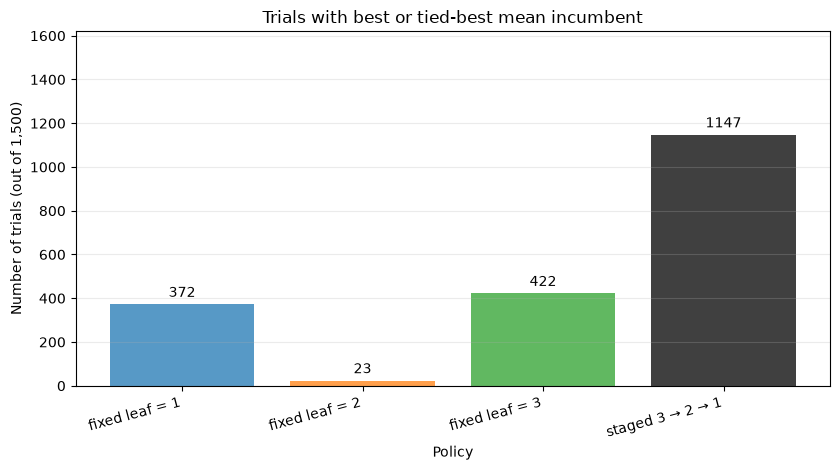

fixed_leaf_1          372
fixed_leaf_2           23
fixed_leaf_3          422
staged_leaf_3_2_1    1147
dtype: int64

In [6]:
mean_regret = trajectories.pivot_table(
    index="iteration",
    columns="policy",
    values="best_regret",
    aggfunc="mean",
)
best_at_iteration = mean_regret.min(axis=1)
is_best_or_tied = pd.DataFrame(
    {
        policy: np.isclose(
            mean_regret[policy], best_at_iteration, rtol=1e-12, atol=1e-9
        )
        for policy in POLICIES
    },
    index=mean_regret.index,
)
best_counts = is_best_or_tied.sum().reindex(POLICIES)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
bars = ax.bar(
    [LABELS[policy] for policy in POLICIES],
    best_counts.to_numpy(),
    color=("C0", "C1", "C2", "black"),
    alpha=0.75,
)
ax.bar_label(bars, padding=3)
ax.set(
    title="Trials with best or tied-best mean incumbent",
    xlabel="Policy",
    ylabel="Number of trials (out of 1,500)",
    ylim=(0, N_TRIALS * 1.08),
)
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

best_counts

## Number of final 300 trials at which each policy was best

This repeats the comparison above using only iterations 1,201 through 1,500. Every policy tied for the lowest mean regret receives credit.

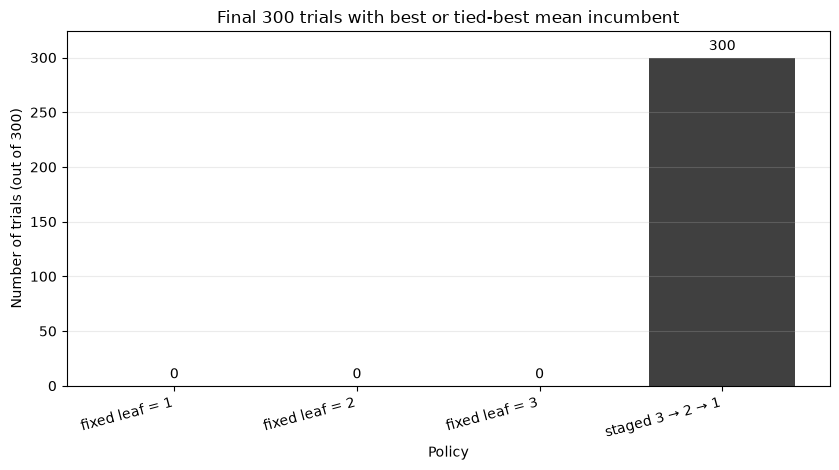

fixed_leaf_1           0
fixed_leaf_2           0
fixed_leaf_3           0
staged_leaf_3_2_1    300
dtype: int64

In [7]:
FINAL_WINDOW = 300
final_trajectories = trajectories[
    trajectories["iteration"] > N_TRIALS - FINAL_WINDOW
]
final_mean_regret = final_trajectories.pivot_table(
    index="iteration",
    columns="policy",
    values="best_regret",
    aggfunc="mean",
)
final_best_at_iteration = final_mean_regret.min(axis=1)
final_is_best_or_tied = pd.DataFrame(
    {
        policy: np.isclose(
            final_mean_regret[policy],
            final_best_at_iteration,
            rtol=1e-12,
            atol=1e-9,
        )
        for policy in POLICIES
    },
    index=final_mean_regret.index,
)
final_best_counts = final_is_best_or_tied.sum().reindex(POLICIES)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
bars = ax.bar(
    [LABELS[policy] for policy in POLICIES],
    final_best_counts.to_numpy(),
    color=("C0", "C1", "C2", "black"),
    alpha=0.75,
)
ax.bar_label(bars, padding=3)
ax.set(
    title="Final 300 trials with best or tied-best mean incumbent",
    xlabel="Policy",
    ylabel="Number of trials (out of 300)",
    ylim=(0, FINAL_WINDOW * 1.08),
)
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

final_best_counts